<a href="https://colab.research.google.com/github/swapnil-fegade/AppointUs-PBL/blob/main/25DLS495_Week2_day3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

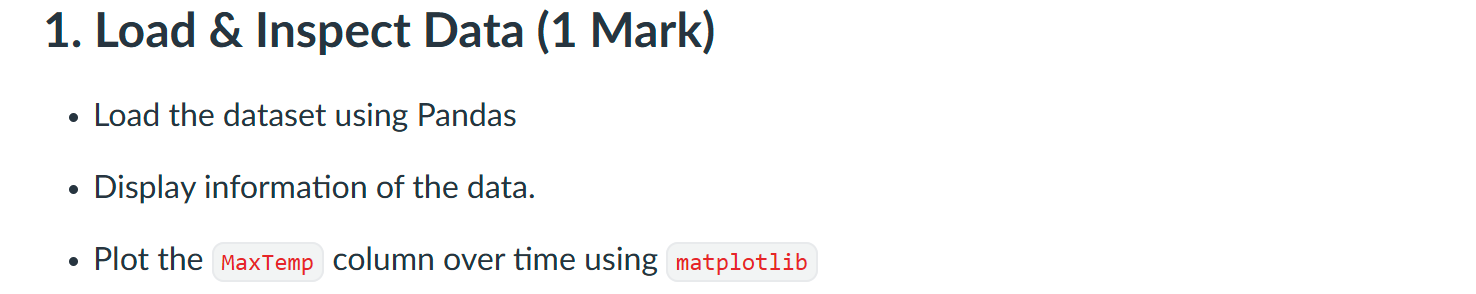

In [2]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "DailyDelhiClimateTrain.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "sumanthvrao/daily-climate-time-series-data",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

<ipython-input-2-ca937f65f0ad>:10: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 76.4k/76.4k [00:00<00:00, 2.18MB/s]

First 5 records:          date   meantemp   humidity  wind_speed  meanpressure
0  2013-01-01  10.000000  84.500000    0.000000   1015.666667
1  2013-01-02   7.400000  92.000000    2.980000   1017.800000
2  2013-01-03   7.166667  87.000000    4.633333   1018.666667
3  2013-01-04   8.666667  71.333333    1.233333   1017.166667
4  2013-01-05   6.000000  86.833333    3.700000   1016.500000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


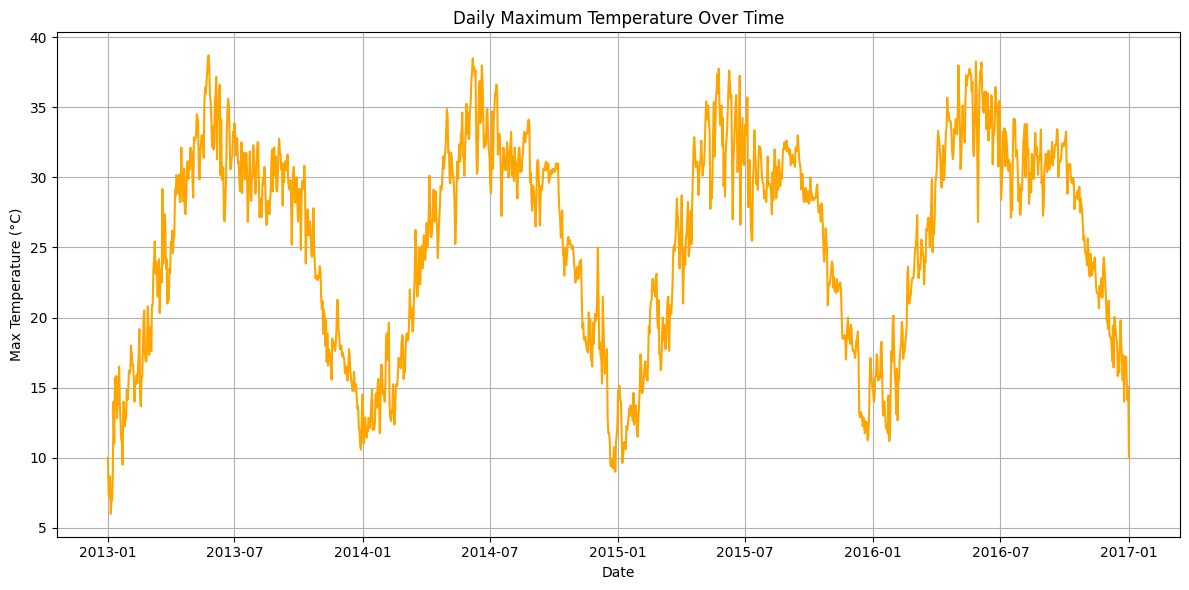

In [17]:
# Convert date column to datetime format for plotting
df['date'] = pd.to_datetime(df['date'])

# Plot the MaxTemp column over time
plt.figure(figsize=(12, 6))
plt.plot(df['date'], df['meantemp'], color='orange')
plt.title('Daily Maximum Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Max Temperature (°C)')
plt.grid(True)
plt.tight_layout()
plt.show()

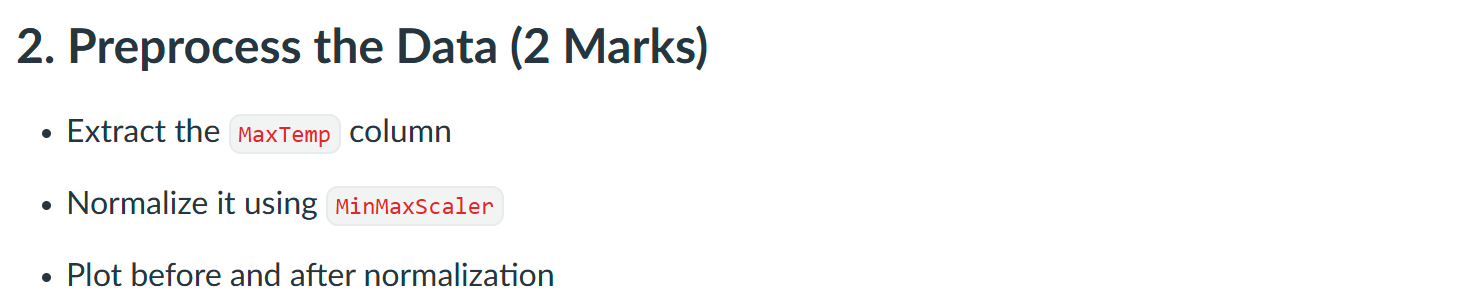

In [3]:
from IPython import get_ipython
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
max_temp = df[['meantemp']].values

In [26]:
max_temp

array([[10.        ],
       [ 7.4       ],
       [ 7.16666667],
       ...,
       [14.0952381 ],
       [15.05263158],
       [10.        ]])

In [29]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [32]:
max_temp_scaled = scaler.fit_transform(max_temp)

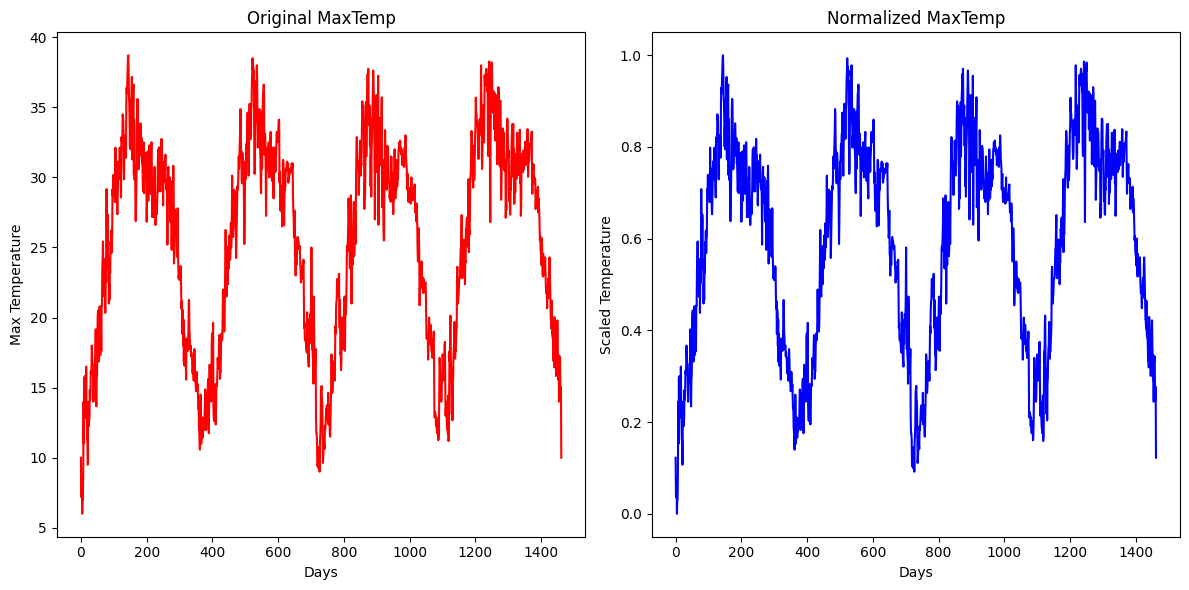

In [35]:
# Plot before and after normalization
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(max_temp, label='Original', color='red')
plt.title('Original MaxTemp')
plt.xlabel('Days')
plt.ylabel('Max Temperature')

plt.subplot(1, 2, 2)
plt.plot(max_temp_scaled, label='Normalized', color='blue')
plt.title('Normalized MaxTemp')
plt.xlabel('Days')
plt.ylabel('Scaled Temperature')

plt.tight_layout()
plt.show()

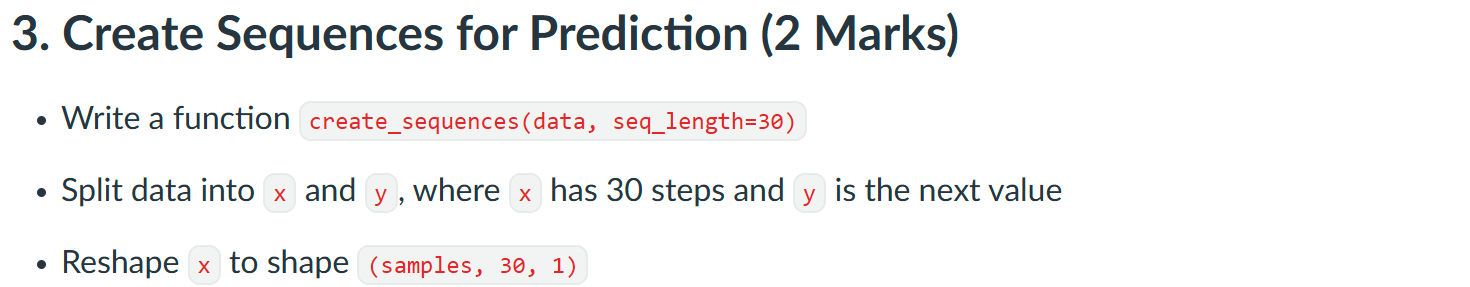

In [36]:
import numpy as np

def create_sequences(data, seq_length=30):
    x, y = [], []
    for i in range(len(data) - seq_length):
        x.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(x), np.array(y)

x, y = create_sequences(max_temp_scaled)
x = x.reshape((x.shape[0], x.shape[1], 1))
print(f'x shape: {x.shape}, y shape: {y.shape}')

x shape: (1432, 30, 1), y shape: (1432, 1)


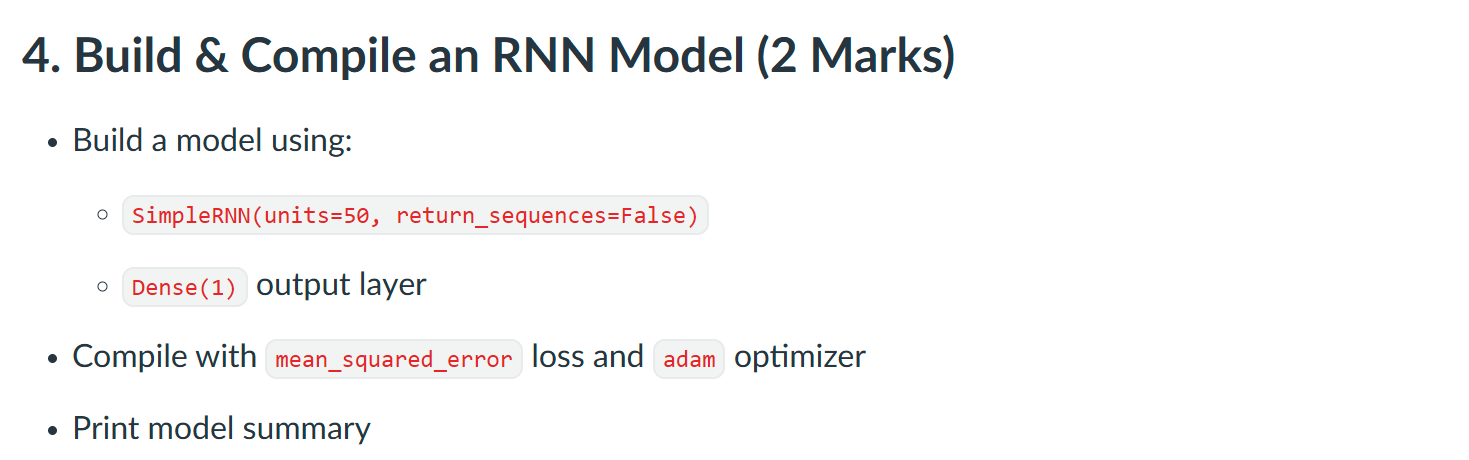

In [39]:
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense

In [41]:
model = Sequential()
model.add(SimpleRNN(units=32, return_sequences=False))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['accuracy'])
model.build(input_shape=(None, 30, 1))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

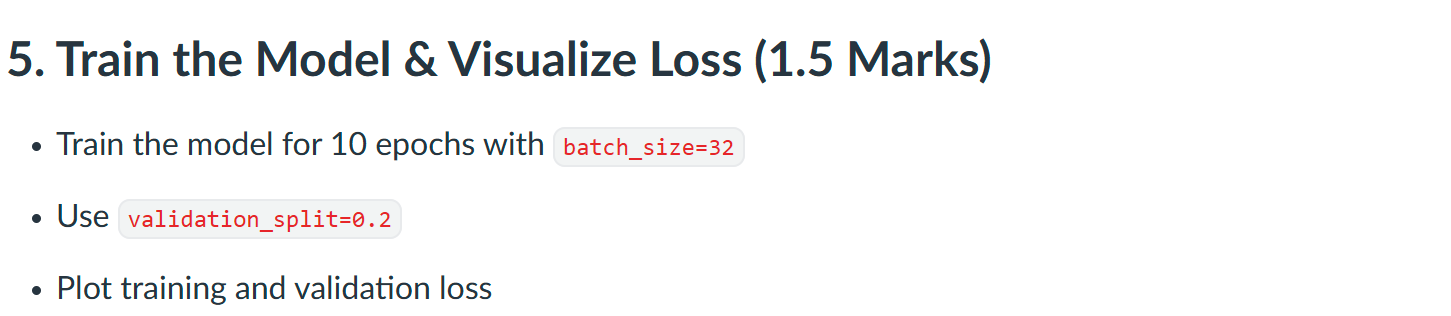

In [43]:
history = model.fit(x, y, 32, 10, validation_split=0.2)

Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 4.7209e-05 - loss: 0.3682 - val_accuracy: 0.0000e+00 - val_loss: 0.0180
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 4.7071e-04 - loss: 0.0162 - val_accuracy: 0.0000e+00 - val_loss: 0.0124
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0014 - loss: 0.0108 - val_accuracy: 0.0000e+00 - val_loss: 0.0092
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 2.3269e-04 - loss: 0.0093 - val_accuracy: 0.0000e+00 - val_loss: 0.0079
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 9.9899e-04 - loss: 0.0081 - val_accuracy: 0.0000e+00 - val_loss: 0.0071
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 4.7071e-04 - loss: 0.0071 - val_accuracy: 0.0000e+00 - val_loss: 0.0062
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0035 - loss: 0.0063 - val_accuracy: 0.0000e+00 - val_loss: 0.0063
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 7.4700e

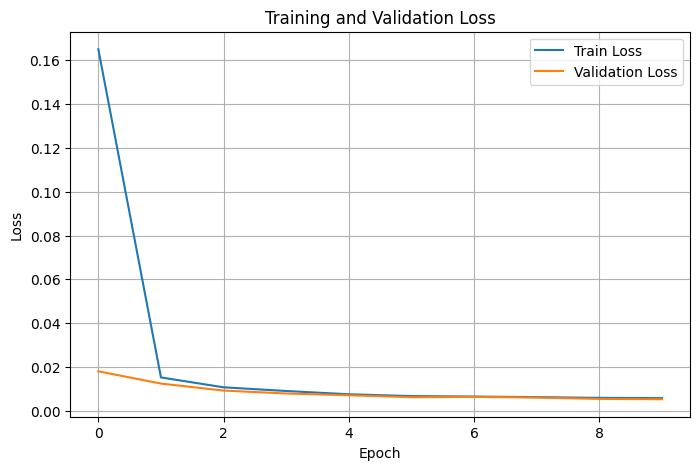

In [51]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

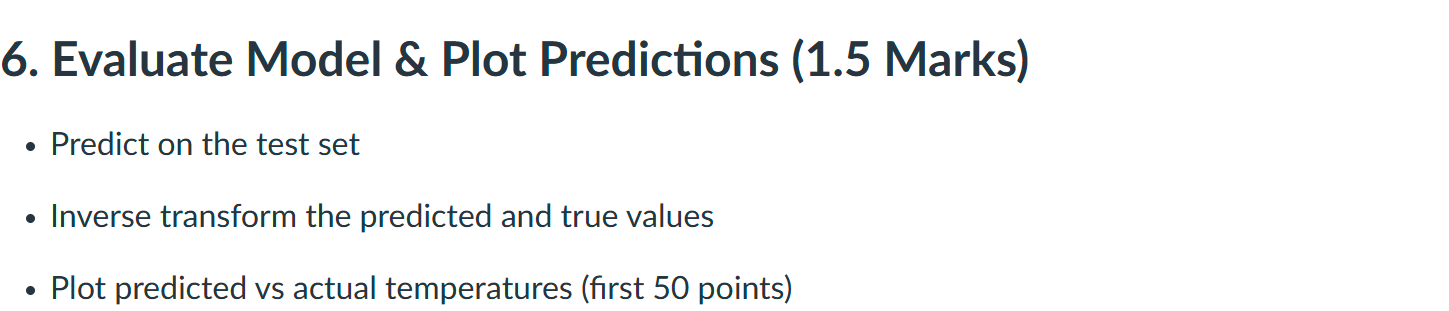

In [52]:
predictions = model.predict(x)
predictions_inv = scaler.inverse_transform(predictions)
y_inv = scaler.inverse_transform(y)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


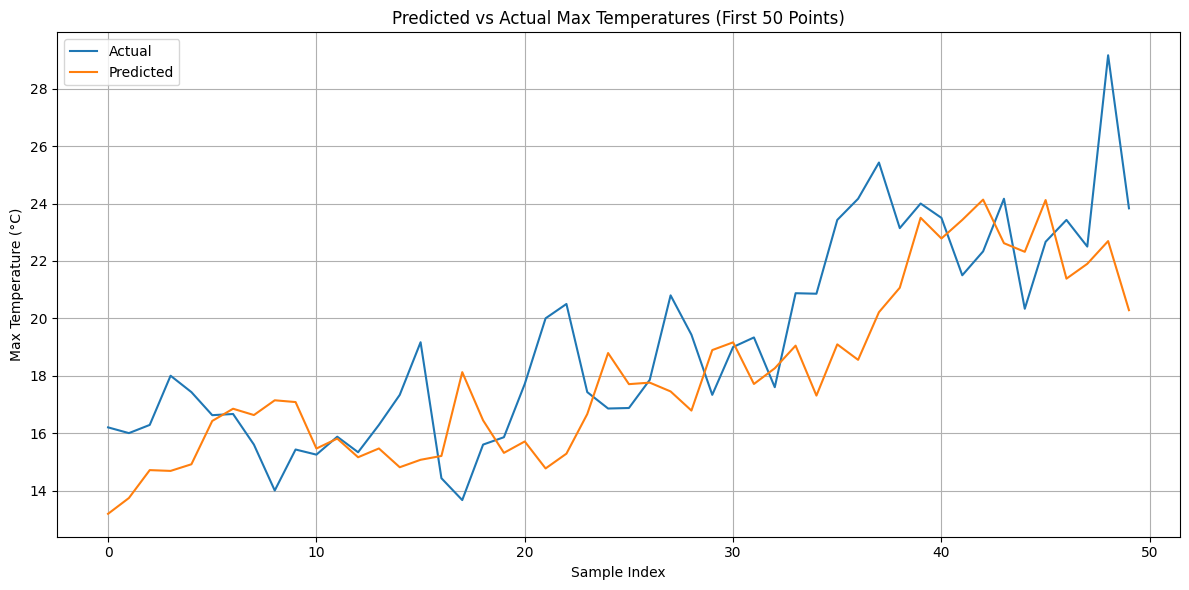

In [55]:
plt.figure(figsize=(12, 6))
plt.plot(y_inv[:50], label='Actual')
plt.plot(predictions_inv[:50], label='Predicted')
plt.title('Predicted vs Actual Max Temperatures (First 50 Points)')
plt.xlabel('Sample Index')
plt.ylabel('Max Temperature (\u00b0C)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()